# Fake News Detection — EDA & Model Training

This notebook does two things, in order:

1. **Exploratory Data Analysis (EDA)** — load the WELFake dataset, look at its shape, check for missing values, and visualise how many "real" vs "fake" articles it contains.
2. **Model training** — clean the article text, turn it into numbers with TF-IDF, train three different classifiers, compare them, and save the best one to disk so `app.py` (the Flask web app) can load it later.

**Label meaning in this dataset:** `0` = Real news, `1` = Fake news.

Run the cells from top to bottom. The first run will be slower because text cleaning and model training take real computation — later cells depend on variables created in earlier ones, so don't skip around.

In [1]:
# pandas: load and explore tabular data (our CSV of news articles)
# matplotlib/seaborn: draw charts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the WELFake dataset. 
df = pd.read_csv('data/WELFake_Dataset.csv')

print("Shape:", df.shape)  # (number of articles, number of columns)

print("\nLabel counts:")
print(df['label'].value_counts())  # how many fake (1) vs real (0) articles

df.head(3)  # preview at the first 3 rows to see what the data looks like

Shape: (72134, 4)

Label counts:
label
1    37106
0    35028
Name: count, dtype: int64


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


Missing values:
 Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

After cleaning: (71537, 4)


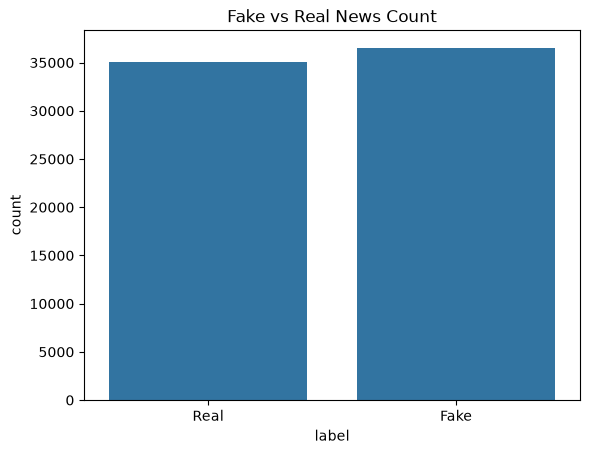

In [2]:
# Check missing values and clean
# Some rows have an empty title or text — a model can't learn from missing
# text, so we just drop any row with a missing value rather than guessing.
print("Missing values:\n", df.isnull().sum())
df = df.dropna()
print("\nAfter cleaning:", df.shape)

# Plot how many fake vs real articles we have. This matters because a big
# imbalance (e.g. 90% fake, 10% real) would make accuracy a misleading
# metric — here the classes are close to balanced, which is good.
sns.countplot(x='label', data=df)
plt.xticks([0, 1], ['Real', 'Fake'])
plt.title('Fake vs Real News Count')
plt.savefig('models/label_chart.png')  # save the chart as an image file
plt.show()

In [3]:
# Text cleaning step.
# Machine learning models can't read raw English the way humans do — we
# need to strip out noise (punctuation, numbers, capitalisation) and
# "stopwords" (common filler words like "the", "is", "and") that carry
# little meaning on their own, so the model can focus on words that
# actually help distinguish fake from real news.
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)  # one-time download of the stopword list
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                       # lowercase everything
    text = re.sub(r'[^a-z\s]', '', text)            # keep only letters and spaces
    words = [w for w in text.split() if w not in stop_words]  # drop stopwords
    return ' '.join(words)

print("Cleaning text... (takes ~30 seconds)")
df['clean'] = df['text'].apply(clean_text)  # apply the cleaning to every article
print("Done!")
print(df['clean'].head(2))

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1020)>


Cleaning text... (takes ~30 seconds)


Done!
0    comment expected barack obama members fyf fuky...
2    demonstrators gathered last night exercising c...
Name: clean, dtype: str


In [4]:
# Save the cleaned dataset as its own CSV file (separate from the original
# raw data) so it can be inspected outside this notebook — e.g. opened in
# Excel, or handed in alongside the project report.
df[['title', 'text', 'clean', 'label']].to_csv('data/WELFake_cleaned.csv', index=False)
print("Saved cleaned dataset to data/WELFake_cleaned.csv")

Saved cleaned dataset to data/WELFake_cleaned.csv


In [5]:
# Turn cleaned text into numbers a model can learn from, using TF-IDF
# (Term Frequency – Inverse Document Frequency). In short: it scores each
# word higher if it's frequent in THIS article but rare across all
# articles — that makes distinctive words stand out more than generic ones.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pickle

X = df['clean']   # the cleaned article text (input)
y = df['label']   # 0 = real, 1 = fake (what we want to predict)

# Split data: 80% to train the model, 20% held back to test it on
# articles it has never seen. random_state=42 just makes the split
# reproducible (same split every time you run this).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# max_features=5000 keeps only the 5000 most informative words, which
# keeps the model fast and avoids overfitting on rare/one-off words.
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)  # learn vocabulary + transform training text
X_test_tfidf  = tfidf.transform(X_test)       # reuse that same vocabulary on test text

print("Train shape:", X_train_tfidf.shape)
print("Test shape: ", X_test_tfidf.shape)

# Save everything needed later (train/test data + the fitted vectorizer)
# so app.py can load the same tfidf without re-fitting it from scratch.
with open('models/data.pkl', 'wb') as f:
    pickle.dump((X_train_tfidf, X_test_tfidf, y_train, y_test, tfidf), f)
print("Saved!")

Train shape: (57229, 5000)
Test shape:  (14308, 5000)
Saved!


In [6]:
# Try a few different classification algorithms and compare their accuracy
# on the held-out test set, so we can pick the best one to ship in the app.
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),  # linear model, usually strong on TF-IDF text
    'Naive Bayes':         MultinomialNB(),                    # fast probabilistic baseline, classic for text
    'Decision Tree':       DecisionTreeClassifier(max_depth=10)  # depth capped to avoid overfitting
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)        # train on the training split
    preds = model.predict(X_test_tfidf)      # predict on unseen test split
    acc = accuracy_score(y_test, preds)      # % of correct predictions
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 94.95%
Naive Bayes: 85.04%


Decision Tree: 91.49%


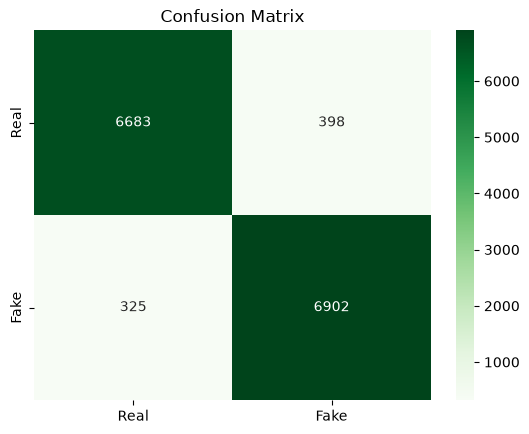

              precision    recall  f1-score   support

        Real       0.95      0.94      0.95      7081
        Fake       0.95      0.96      0.95      7227

    accuracy                           0.95     14308
   macro avg       0.95      0.95      0.95     14308
weighted avg       0.95      0.95      0.95     14308



In [7]:
# Logistic Regression won the comparison above, so retrain it (this time
# we keep the fitted object as `best` so the very next cell can reuse it)
# and save it to disk — this is the file app.py loads to serve predictions.
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# Use best model
best = LogisticRegression(max_iter=1000)
best.fit(X_train_tfidf, y_train)
preds = best.predict(X_test_tfidf)

# Save model
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best, f)

# Confusion matrix: rows = actual label, columns = predicted label.
# The diagonal (top-left to bottom-right) is what the model got right;
# anything off the diagonal is a mistake (false positive/negative).
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.savefig('models/confusion_matrix.png')
plt.show()

# precision/recall/f1 per class — more informative than accuracy alone,
# especially for spotting whether the model favours one class over the other
print(classification_report(y_test, preds, target_names=['Real', 'Fake']))

In [8]:
# Quick manual sanity check: run a couple of made-up headlines through the
# trained model to see if its predictions look sensible before trusting it
# in the actual web app.
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def predict(text):
    text = re.sub(r'[^a-z\s]', '', text.lower())                  # same cleaning as training
    text = ' '.join([w for w in text.split() if w not in stop_words])
    vec  = tfidf.transform([text])        # reuse the SAME fitted vectorizer (don't re-fit!)
    pred = best.predict(vec)[0]           # 0 = real, 1 = fake
    prob = best.predict_proba(vec)[0]     # [P(real), P(fake)]
    label = "🚨 FAKE" if pred == 1 else "✅ REAL"
    print(f"{label}  —  {max(prob)*100:.1f}% confident")

predict("Scientists discover cure for cancer using bananas")
predict("Federal Reserve raises interest rates by 0.25 percent")

🚨 FAKE  —  90.0% confident
🚨 FAKE  —  66.7% confident
